# VIIRS Boat Detection Algorithm

## A. Import Modules

In [60]:
# # Uncomment if needed to install packages
# !pip install tqdm
# !pip install netCDF4
# !pip install PyQt5
# !pip install pandas
# !pip install numpy
# !pip install scipy
# !pip install matplotlib
# !pip install simplekml
# !pip install geopandas
# !pip install pygeos
# !pip install rtree

Defaulting to user installation because normal site-packages is not writeable


In [1]:
# File Open GUI
# by Steve Byrnes - https://stackoverflow.com/questions/20790926/ipython-notebook-open-select-file-with-gui-qt-dialog
%gui qt

from PyQt5.QtWidgets import QFileDialog

def uigetfile(dir=None):
    """Select a file via a dialog and return the file name."""
    if dir is None: dir ='./'
    fname = QFileDialog.getOpenFileName(None, "Select data file...", 
                dir, filter="All files (*);; SM Files (*.sm)")
    return fname[0]

In [2]:
# Progress Bar
from tqdm import tqdm

In [3]:
# To read netCDF4 Data
import netCDF4 as nc
from netCDF4.utils import ncinfo

ModuleNotFoundError: No module named 'netCDF4'

In [123]:
# For processing
import numpy as np
import pandas as pd
import cv2
from scipy.signal import wiener
from scipy.signal import medfilt2d
from scipy.signal import hann
import scipy
import matplotlib.pyplot as plt
import copy
import simplekml
import geopandas as gpd
from shapely.geometry import Point
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import os


## B. Local Modules

### B.1. blk_amp_spec_slope_eo_toy

In [12]:
def blk_amp_spec_slope_eo_toy(blk): 
    global N
    global wnd
    
    N = np.size(blk, 1)
    wnd = hann(34)[1:-1][np.newaxis]
    wnd = np.matmul(wnd.T, wnd)
    
    
    blk_wnd_prod = np.multiply(blk, wnd)
    f, a = eo_polaraverage(np.abs(np.fft.fft2(blk_wnd_prod)))
    
    p = np.polyfit(np.log(f),np.log(a),1)
    res = [-p[0], p[1]]
    return res


### B.2. EO_Polaraverage

In [13]:
def eo_polaraverage(data): 
    # conversion cartesian to polar and average from 0 [rad] to rr [rad] step
# rr/dr [rad]
# return value excludes average and includes nyquist frequency spectrum
    
    # usage:
# s = eo_polaraverage(fftdata)
# [f s] = eo_polaraverage(fftdata)
    
    # $Revision: 1.1 $
# $Date: 2006/08/07 02:57:43 $
# $Author: kannon $
    
    rr = 2 * np.pi
    dr = 360
    n = len(data)
    # average = data(1,1)
    data[0,0] = (data[1,0] + data[0,1]) / 2

    s = [0]
    #for r = 0:(n/2-1)
    for r in range(1, int(n/2) + 1):
        zs = 0
        for ith in range(0, dr):
            th = ith / dr
            x = r * np.sin(th * rr)
            y = r * np.cos(th * rr)
            x1 = np.sign(x) * np.floor(np.abs(x))
            x2 = np.sign(x) * np.ceil(np.abs(x))
            y1 = np.sign(y) * np.floor(np.abs(y))
            y2 = np.sign(y) * np.ceil(np.abs(y))

            ex = np.abs(x - x1)
            ey = np.abs(y - y1)
            
            if (x2 < 0):
                ex = np.abs(x - x2)
                if (x1 < 0):
                    x1 = n + x1
                x2 = n + x2
                
            if (y2 < 0):
                ey = np.abs(y - y2)
                if (y1 < 0):
                    y1 = n + y1
                y2 = n + y2
            
            f11 = data[int(x1),int(y1)]
            f12 = data[int(x1),int(y2)]
            f21 = data[int(x2),int(y1)]
            f22 = data[int(x2),int(y2)]
            #z = interp2([0 10 1], [0 01 1], [f11 f21f12 f22], ex, ey, 'linear')
            z = (f21 - f11) * ex * (1 - ey) + (f12 - f11) * (1 - ex) * ey + (f22 - f11) * ex * ey + f11
            
            zs = zs + z
            
        s += [zs / dr]
    
    f = np.linspace(0,0.5,len(s))
    s = s[1:]
    f = f[1:]
#     if (nargout >= 2):
#         x = f
#         y = s
#     else:
#         x = s
    
    return f,s

### B.3. Contrast_map_Overlap

In [14]:
def contrast_map_overlap(img): 
    #input must be double, range 0:255
    img_lum = (0.7656 + 0.0364 * img) ** 2.2
    blk_size = 8
    d_blk = int(blk_size/2)
    num_rows, num_cols = img_lum.shape
    cnt_map = np.zeros((num_rows,num_cols))
    
    for r in np.arange(0, num_rows-d_blk, d_blk).reshape(-1):
        for c in np.arange(0, num_cols-d_blk, d_blk).reshape(-1):
            blk = img_lum[r:r+blk_size,c:c+blk_size]
            m_lum = np.mean(blk)
            if m_lum > 127.5:
                blk = 255 - blk
                m_lum = np.mean(blk)
            if (m_lum > 2 and np.amax(blk) - np.amin(blk) > 5):
                contrast = np.std(blk) / m_lum
                # has enough brightness and some
# variant ...
            else:
                contrast = 0
            if (contrast > 5):
                contrast = 5
            cnt_map[r:r+d_blk, c:c+d_blk] = contrast / 5
    
    # figure; imshow(cnt_map, []);
    return cnt_map

## C. Local Functions

### C.1. Reorient

In [15]:
def reorient(input_data):
# observation data should be rotated 90 clockwise and flipped vertical
    data = np.rot90(input_data)
    data = np.flip(data)
    return data

### C.2. Spike Height Indexing (SHI)

In [16]:
def spikeHeightIndexing(DNB_E9,row,col):
    SHI = np.zeros((row,col))
    row -= 1
    col -= 1
    
    for a in range(1,row):
        # for the most left side
        SP = DNB_E9[a,0]
        APv = (DNB_E9[a-1,0] + DNB_E9[a+1,0])/2 # average of top and bot px
        APh = DNB_E9[a,1]
        SHIv = (SP-APv)/SP
        SHIh = (SP-APh)/SP
        SHI[a,0] = min(SHIv,SHIh)

        # for the most right side
        SP = DNB_E9[a,col]
        APv = (DNB_E9[a-1,col]+DNB_E9[a+1,col])/2 #average of top and bot px
        APh = DNB_E9[a,col-1]
        SHIv = (SP-APv)/SP
        SHIh = (SP-APh)/SP
        SHI[a,col] = min(SHIv,SHIh)
        
        for b in range(1, col): 
            SP = DNB_E9[a,b] # subject px
            APv = (DNB_E9[a-1,b] + DNB_E9[a+1,b])/2 # average of top and bot px
            
            if np.isnan(APv) == 1: APv = np.amax(DNB_E9[a-1,b],DNB_E9[a+1,b]) 
            APh = (DNB_E9[a,b-1] + DNB_E9[a,b+1]) / 2 # avg of left and right px
            if np.isnan(APh) == 1: APh = np.amax(DNB_E9[a,b-1],DNB_E9[a,b+1]) 

            SHIv = (SP-APv) / SP
            SHI[a,b] = min(SHIv,SHIh)
            
    for b in range(1,col):
        # top 
        SP = DNB_E9[1,b]
        APv = DNB_E9[2,b]
        APh = (DNB_E9[1,b-1] + DNB_E9[1,b+1])/2
        SHIv = (SP-APv)/SP
        SHIh = (SP-APh)/SP
        SHI[1,b] = min(SHIv,SHIh)
        
        # top
        SP = DNB_E9[row,b]
        APv = DNB_E9[row-1,b] # average of top and bot px
        APh = (DNB_E9[row,b-1]+DNB_E9[row,b+1])/2
        SHIv = (SP-APv)/SP
        SHIh = (SP-APh)/SP
        SHI[0,b] = min(SHIv,SHIh)
        
    SP = DNB_E9[0,0]
    APv = DNB_E9[1,0]
    APh = DNB_E9[0,1]
    SHIv = (SP-APv)/SP
    SHIh = (SP-APh)/SP
    SHI[0,0] = min(SHIv,SHIh)

    SP = DNB_E9[row,0]
    APv = DNB_E9[row-1,0]
    APh = DNB_E9[row,1]
    SHIv = (SP-APv)/SP
    SHIh = (SP-APh)/SP
    SHI[row,0] = min(SHIv,SHIh)
    SP = DNB_E9[0,col]
    APv = DNB_E9[1,col-1]
    APh = DNB_E9[0,col-1]
    SHIv = (SP-APv)/SP
    SHIh = (SP-APh)/SP
    SHI[0,col] = min(SHIv,SHIh)

    SP = DNB_E9[row,col]
    APv = DNB_E9[row-1,col]
    APh = DNB_E9[row,col-1]
    SHIv = (SP-APv)/SP
    SHIh = (SP-APh)/SP
    SHI[row,col] = min(SHIv,SHIh)
    return SHI

### C.3. Sharpness Indexing

In [17]:
def sharpnessIndexing(DNB_log):
    

    # =================================================================================================
    #                                          S3 MAP
    # =================================================================================================
    
    def s3_map(img, show_res):
        # Input: img is a gray scale image, in double type, range from 0 - 255. 
        # You have to convert to gray scale if your image
        # is color. You also have to cast img to double in order to run this code
        # Parameter show_res = 1 to show results
        # Output:   
        # s_map1: The sharpness map measure based on spectral slope
        # s_map2: The sharpness map measure based on total variation (spatial)            
        # s3: the final sharpness map (combination of s_map1 and s_map2)
#         if len(varargin) < 2:
#             show_res = 0
        # ----------------------------------------------------------------------
        # blr_map1
        s_map1 = spectral_map(img, 16)
        print("s_map1")
        plt.imshow(s_map1)

        #-----------------------------------------------------------------------
        # blr_map2
        s_map21 = spatial_map(img, 8) # Spatial map, blocks start from (1,1)
        s_map22 = spatial_map(img, 4) # Spatial map, blocks start from (5,5) 
        s_map2 = np.maximum(s_map21, s_map22)
        print("s_map2")
        plt.imshow(s_map2)

        #-----------------------------------------------------------------------
        # combine
        s_map1[s_map1 < -99] = 0
        s_map2[s_map2 < -99] = 0
        # s_map2 = np.pad(s_map2, ((0, 2),(0, 1)))
        # For fixing
        print(s_map1.shape)
        print(s_map2.shape)

        ##############
        alpha = 0.5
        s3 = (s_map1**alpha) * ((s_map2)**(1-alpha))
        print("s3")
        plt.imshow(s3)
        
        return s3
    
            #     if show_res:
            # figure
            # imshow(s_map1)
            # figure
            # imshow(s_map2)
            # figure
            # imshow(img / 255)
            # figure
            # imshow(s3)
    
    # =================================================================================================
    #                            Spectral Sharpness, slope of power spectrum
    # =================================================================================================
    
    ## Spectral Sharpness, slope of power spectrum
    def spectral_map(img, pad_len):
        blk_size = 32 #big block size for more coefficients of the power spectrum

        d_blk = int(blk_size/4) # Distance b/w blocks

        pad_L = np.fliplr(img[:,:pad_len])  # Take 16 columns on the left of the
                                              # original image to pad to the left
        pad_R = np.fliplr(img[:,np.arange(-1-pad_len,0)])
                
        img = np.hstack((pad_L, img, pad_R)) 

        pad_T = np.flipud(img[:pad_len, :])     # Similarly, pad top and bottom
        pad_B = np.flipud(img[np.arange(-1-pad_len,0),:])
        img = np.concatenate((pad_T, img, pad_B))

        num_rows, num_cols = img.shape
        res = np.zeros((num_rows, num_cols)) - 100
        contrast_thresold = 0

        blk_half = int(blk_size/2)
        d_blk_half = int(d_blk/2)

        # Just start from inside blocks of the padded image
        for r in tqdm(range(blk_half, num_rows-blk_half, d_blk)):
            r = int(r)
            for c in range(blk_half, num_cols-blk_half, d_blk):    
                c = int(c)
                # print(r,c)
                gry_blk = img[int(r-blk_half):int(r+blk_half), int(c-blk_half):int(c+blk_half)]
        #         gry_blk = img[np.arange(int(r - blk_size / 2),int(r + blk_size / 2)),np.arange(int(c - blk_size / 2),int(c + blk_size / 2))]
        #         gry_blk = img[np.arange(r- blk_half),r+ blk_half-1+1), np.arange(c- blk_half,c+ blk_half)]
                contrastMap = contrast_map_overlap(gry_blk)
                if (np.amax(contrastMap[:]) > contrast_thresold):
                    val = blk_amp_spec_slope_eo_toy(gry_blk)
                    # power spectrum of the block
                    # print(val)
                    val[0] = 1 - 1 / (1 + np.exp(-3*(val[0] - 2)))
                    #if(max(gry_blk(:))==min(gry_blk(:))) # Black block
                    val_1 = val[0]
                    
                
                else:
                    val_1 = 0

                res[r-d_blk_half:r+d_blk_half,c-d_blk_half:c+d_blk_half] = val_1
        # Remove padded parts
        spectral_map_final = res[pad_len:-1-pad_len, pad_len:-1-pad_len]
        return spectral_map_final
        
    # =================================================================================================
    #                            Spatial Sharpness, local total variation
    # =================================================================================================
    
    def spatial_map(img, pad_len):
        # pad_len = 8 if we dont want to shift img
        # pad_len = 4 if we want to shift img by 4
        blk_size = 8

        pad_L = np.fliplr(img[:,:pad_len])  # Take 16 columns on the left of the
                                              # original image to pad to the left
                                              #Take 16 columns on the right of the
                                                    # original image to pad to the
                                                    # right
                
        pad_R = np.fliplr(img[:,np.arange(-1-pad_len,0)])
        img = np.hstack((pad_L, img, pad_R)) 

        pad_T = np.flipud(img[:pad_len, :])     # Similarly, pad top and bottom
        pad_B = np.flipud(img[np.arange(-1-pad_len,0),:])
        img = np.concatenate((pad_T, img, pad_B))

        [num_rows, num_cols] = np.shape(img)
        res = np.zeros((num_rows, num_cols))

        blk_half = int(blk_size/2)

        for r in tqdm(range(int(blk_size/2), int(num_rows-blk_size/2), int(blk_size))):
            for c in range(int(blk_size/2), int(num_cols-blk_size/2), int(blk_size)):
                gry_blk = img[int(r-blk_size/2):int(r+blk_size/2), int(c-blk_size/2):int(c+blk_size/2)]
                # Measure local total variation for every 2x2 block of gry_blk
                tmp_idx = 1
                tv_tmp = []
                for i in range(0, blk_size-1):
                    for j in range(0, blk_size-1):
                        tv_tmp += [((abs(gry_blk[i,j] - gry_blk[i,j+1])  
                                              + abs(gry_blk[i,j] - gry_blk[i+1,j]) 
                                              + abs(gry_blk[i,j] - gry_blk[i+1,j+1]) 
                                              + abs(gry_blk[i+1,j+1] - gry_blk[i+1,j]) 
                                              + abs(gry_blk[i+1,j] - gry_blk[i,j+1]) 
                                              + abs(gry_blk[i+1,j+1] - gry_blk[i,j+1]))/255)]
                        
                tv_max = max(tv_tmp) / 4 # Normalize tv_max to be from 0 -1. We can
                                      # easily see that the maximum value of total
                                      # variation for each 2x2 block is 4, in
                                      # blocks like   1 0
                                      #               0 1
                res[r-blk_half:r+blk_half,c-blk_half:c+blk_half] = tv_max

        # Remove padded parts
        spatial_map_final = res[pad_len:-1-pad_len, pad_len:-1-pad_len]
        return spatial_map_final
    
    # all negative data values and NAN are represented as RGB[0,0,0]
    # all positive data values > 1 are represented as RGB[1,1,1]
    
    J_sharp = copy.deepcopy(DNB_log)
    J_sharp[J_sharp > 1] = 1
    Jgray = copy.deepcopy(J_sharp)
    Jgray *= (255.0/J_sharp.max())
    pd.DataFrame(Jgray)
    
    # ????
    SI = s3_map(Jgray, 0)
    return SI

### C.4. No Lightning

In [18]:
def lightningDetection(DNB_log, num_lines, num_pixels, num_scans): 
    #input: DNB_log
    #scan lines is equivalent to columns of DNB observation data
    # 1 feature vector is 16 columns (lines) wide

    # Difference between adj line scans (rows/16).
    # There are 202 scans (segments) x 16 linescans per col (202x16 = 3232 rows)
    # find difference between segments (201 points)
    row = num_lines
    col = num_pixels
    ScanSegDiff = np.zeros((num_scans - 1,col))

    count = 0
    NoLightning = np.ones((row,col))
    for v in range(0, num_scans - 1):
        for w in range(0, col - 1):
            ScanSegDiff[v,w] = DNB_log[v * 16,w] - DNB_log[v * 16 + 1,w]
            #end of 1st segment - last(16th element) of next segment vertically
            if ScanSegDiff[v,w] >= 0.1:
                count = count + 1
            else:
                if np.abs(ScanSegDiff[v,w]) < 0.1 and count >= 24:
                    #lightning detected, discard readings
                    NoLightning[np.arange[v * 16 - 15,v * 16+1],np.arange[w - count,w+1]] = 0
                    count = 0
                else:
                    count = 0

    return NoLightning

### C.5 Quality Flag

In [19]:
def qflagging(DNB_E9,SMI_filtered,NoLightning, SI, SHI, SMI_thresh_mask, land_water_mask, 
              BW, num_lines,num_pixels): 

    VBD_QualityFlags = np.zeros((num_lines,num_pixels))
    # flag_values   = [0  1  2  3  4  5  6  7]
    # flag_meanings = 'Shallow_Ocean Land Coastline Shallow_Inland Ephemeral Deep_Inland Continental Deep_Ocean'
    # convert mask to binary: water = 0, 6, 7
    A = land_water_mask == 0
    B = land_water_mask == 6
    C = land_water_mask == 7
    WaterMask = A + B + C
    #Output of spike detector is SMI_log

    data_offshore = SMI_filtered * WaterMask

    data_noLightning = data_offshore * NoLightning

    SHI = SHI * SMI_thresh_mask
    SHI = SHI * BW
    # QF1 = Strong detection
    # QF2 = Weak detection
    # QF3 = Discarded blurry detections
    # QF4 = gas flares based on M10 Band
    # QF5 = Energetic particle detection
    
    for idx in range(0, num_lines):
        for idy in range(0, num_pixels):
            # QF 4 temporarily bypassed
            if WaterMask[idx,idy] == 1 and NoLightning[idx,idy] == 1 and \
            SMI_thresh_mask[idx,idy] == 1 and BW[idx,idy] == 1:
                if SI[idx,idy] > 0.4:
                    if SHI[idx,idy] > 0.75 and SHI[idx,idy] < 0.995 and DNB_E9[idx,idy] < 1000:
                        # QF1
                        VBD_QualityFlags[idx,idy] = 1
                    elif SHI[idx,idy] < 0.75 and DNB_E9[idx,idy] < 1000:
                            # QF2
                            VBD_QualityFlags[idx,idy] = 2
                else:
                    # QF3
                    VBD_QualityFlags[idx,idy] = 3
                if SHI[idx,idy] > 0.995 and DNB_E9[idx,idy] > 1000:
                    VBD_QualityFlags[idx,idy] = 5

    # remove land
    VBD_QualityFlags = VBD_QualityFlags*WaterMask

    VBD_QualityFlags = VBD_QualityFlags*NoLightning

    VBD_QualityFlags = VBD_QualityFlags*SMI_thresh_mask

    return VBD_QualityFlags
    


In [24]:
def stats(array):
    print("Minimum Value:", np.min(array))
    print("Maximum Value:", np.max(array))
    print("Variance:", np.var(array))
    print("Array Shape:", np.shape(array))

## D. Algorithm

### D.1. Open File

In [33]:
file_VNP02 = nc.Dataset(uigetfile())
file_VNP03 = nc.Dataset(uigetfile())

### D.2. Get Data

In [22]:
# fetch VNPO2 Observation data
DNB_observations = file_VNP02['observation_data']['DNB_observations'][:]

# fetch VNPO3 Geolocation data
Lat = file_VNP03['geolocation_data']['latitude'][:]
Lon = file_VNP03['geolocation_data']['longitude'][:]
land_water_mask = file_VNP03['geolocation_data']['land_water_mask'][:]

# fetch info on netCDF data
num_scans = len(file_VNP02.dimensions['number_of_scans'])
num_lines = len(file_VNP02.dimensions['number_of_lines'])
num_pixels = len(file_VNP02.dimensions['number_of_pixels'])

C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\lib\site-packages\ipykernel_launcher.py:2: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\lib\site-packages\ipykernel_launcher.py:5: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  """
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgisp

### D.2. Pre-Processing

DNB_Observations:
Minimum Value: 3.960574e-14
Maximum Value: 1.2598031e-05
Variance: 3.9940440846357614e-17
Array Shape: (3232, 4064)

DNB_E9:
Minimum Value: 1e-09
Maximum Value: 12598.031389643438
Variance: 39.04965984442438
Array Shape: (3232, 4064)

DNB_log:
Minimum Value: 0.0
Maximum Value: 4.1003026861167235
Variance: 0.010569183091526642
Array Shape: (3232, 4064)



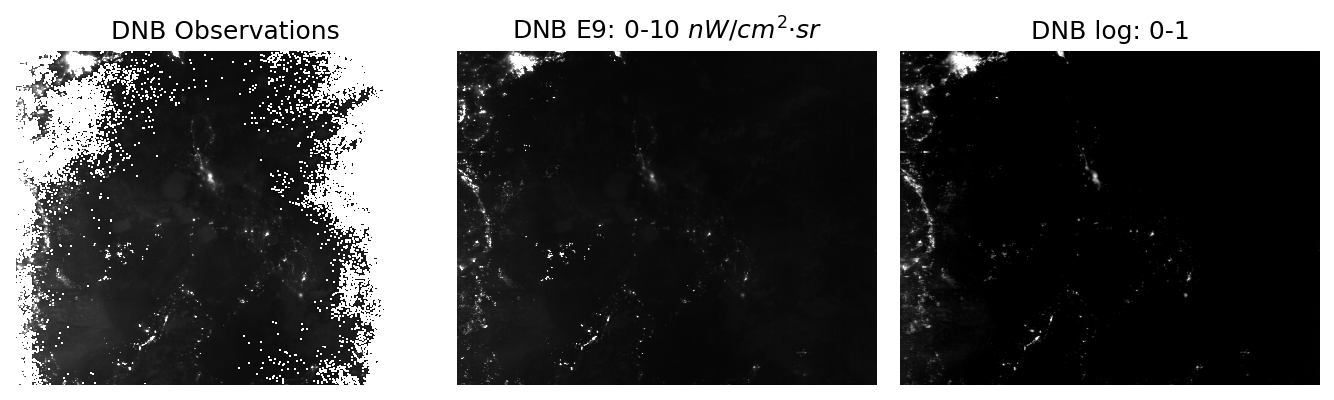

In [25]:
# Pre-processing
# %DNB_observations(DNB_observations<0)=0; %nan;
DNB_E9 = DNB_observations.data * 10**9
DNB_E9[DNB_E9 < 0] = 0.000000001
DNB_E9[np.isnan(DNB_E9)]=0.000000001 
DNB_log = np.log10(DNB_E9)
DNB_log[DNB_log < 0] = 0
# print("DNB_log")

# Sanity Check: Statistically assess the Pre-processed DNB
print("DNB_Observations:")
stats(DNB_observations)
print("")
## ---
print("DNB_E9:")
stats(DNB_E9)
print("")

## ---
print("DNB_log:")
stats(DNB_log)
print("")

fig,ax = plt.subplots(1,3, figsize = [9,3], dpi = 150)
[axi.set_axis_off() for axi in ax.ravel()]

ax[0].set_title("DNB Observations")
ax[0].imshow(DNB_observations, cmap = 'gray', vmin = 0, vmax = 5e-9)

ax[1].set_title("DNB E9: 0-10 $nW/cm^2·sr$")
ax[1].imshow(DNB_E9, cmap = 'gray', vmin = 0, vmax = 10)

ax[2].set_title("DNB log: 0-1" )
ax[2].imshow(DNB_log, cmap = 'gray', vmin = 0, vmax = 1)

plt.tight_layout()

#### D.2.1 Filtering

In [26]:
# # Adaptive Weiner Filter
noise = pd.DataFrame(DNB_log).rolling(7, center=False, axis=0, min_periods=1).var().shift(-3).fillna(0)
J = wiener(DNB_log, (3, 3))
# pd.DataFrame(J)

C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\lib\site-packages\scipy\signal\signaltools.py:1598: RuntimeWarning: divide by zero encountered in true_divide
  res *= (1 - noise / lVar)
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\lib\site-packages\scipy\signal\signaltools.py:1598: RuntimeWarning: invalid value encountered in multiply
  res *= (1 - noise / lVar)


Noise:
DescribeResult(nobs=4064, minmax=(0.0, 0.2723834024691371), mean=0.003483935510152587, variance=0.0002856749571326979, skewness=8.172588268754744, kurtosis=82.73706326494762)

J:
DescribeResult(nobs=3232, minmax=(-1.8713882752529387e-16, 0.027481985277748703), mean=0.008314425645061723, variance=2.4370712715339995e-05, skewness=0.11911428340202877, kurtosis=-0.1298405813106318)

JMed:
DescribeResult(nobs=3232, minmax=(-4.386066270124075e-17, 0.025864535111054264), mean=0.00741246941821098, variance=2.099041938654019e-05, skewness=0.060576663331813434, kurtosis=-0.3195753048154164)



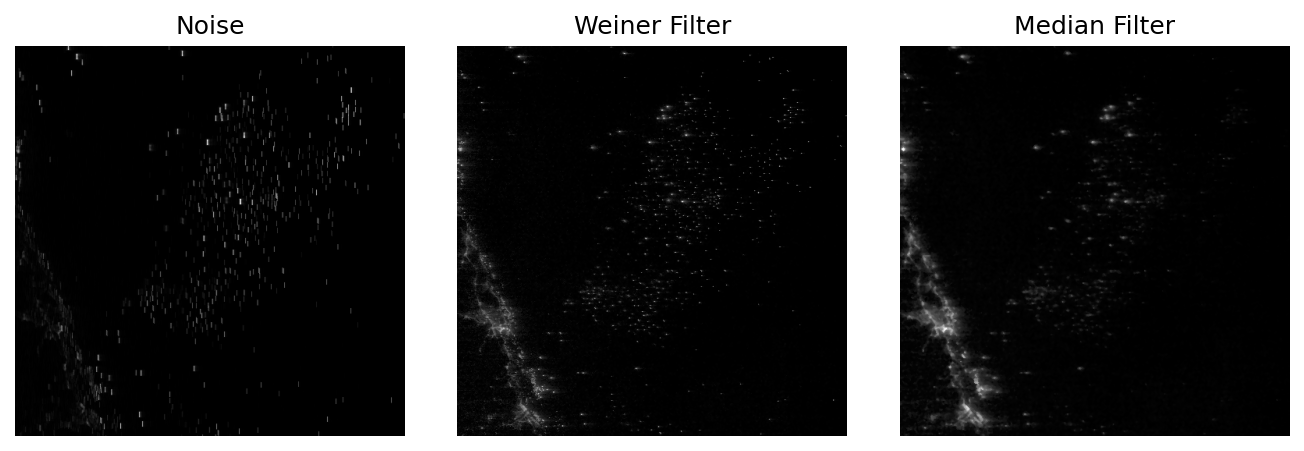

In [27]:
# Median Filter
Jmed = medfilt2d(J,[3,3]) # Jmed is in log10
# Median and Weiner-filtered
# plt.imshow(Jmed)

# Sanity Check: Statistically assess the Weiner and Median Filtered DNB

print("Noise:")
print(scipy.stats.describe(noise.T[0]))
print("")
## ---
print("J:")
print(scipy.stats.describe(J.T[0]))
print("")

## ---
print("JMed:")
print(scipy.stats.describe(Jmed.T[0]))
print("")

fig,ax = plt.subplots(1,3, figsize = [9,3], dpi = 150)
[axi.set_axis_off() for axi in ax.ravel()]

ax[0].set_title("Noise")
ax[0].imshow(np.asarray(noise)[1200:1700, 200:700], cmap = 'gray')#, vmin = 0, vmax = 0.1)

ax[1].set_title("Weiner Filter")
ax[1].imshow(J[1200:1700, 200:700], cmap = 'gray')#, vmin = -1e-16, vmax = 1e17)

ax[2].set_title("Median Filter" )
ax[2].imshow(Jmed[1200:1700, 200:700], cmap = 'gray')#, vmin = -5e-17, vmax = 3e-17)

plt.tight_layout()

### D.3. Indexing

In [28]:
# Indexing
## SMI Generation
Diff = 10**DNB_log - 10**Jmed
Diff[Diff<0.000000001] = 0.000000001
SMI_log = np.log10(Diff)
SMI = 10 ** SMI_log
SMI_thresh_mask = SMI_log > np.log10(0.035)
SMI_filtered = SMI_log * SMI_thresh_mask
# plt.imshow(SMI_filtered)

# pd.DataFrame(SMI_filtered).to_csv("SMI_filtered.csv")

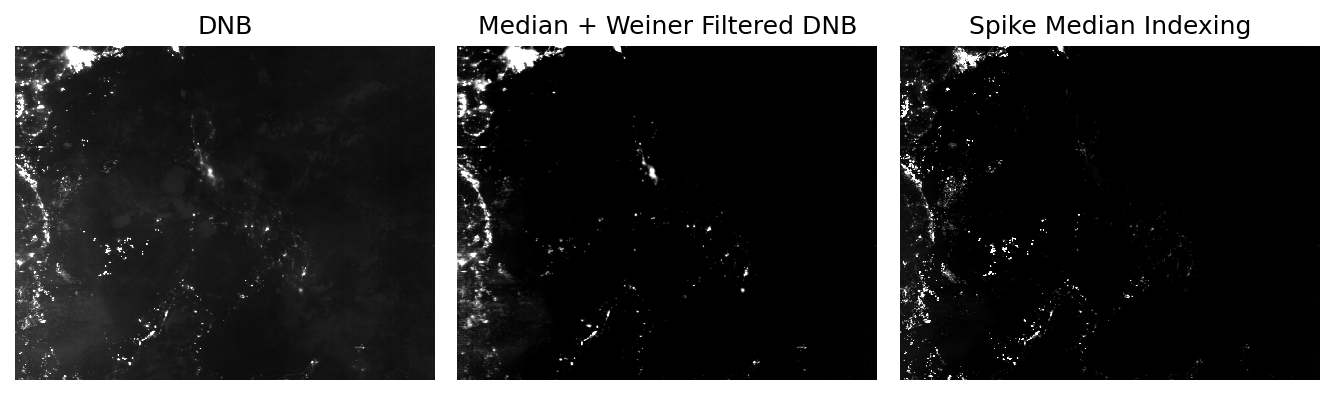

In [29]:
fig,ax = plt.subplots(1,3, figsize = [9,3], dpi = 150)
[axi.set_axis_off() for axi in ax.ravel()]

ax[0].set_title("DNB")
ax[0].imshow(DNB_E9, cmap = 'gray', vmax = 5)

ax[1].set_title("Median + Weiner Filtered DNB")
ax[1].imshow(Jmed, cmap = 'gray', vmax = 0.5)

ax[2].set_title("Spike Median Indexing")
ax[2].imshow(SMI, cmap = 'gray', vmax = 2)

plt.tight_layout()

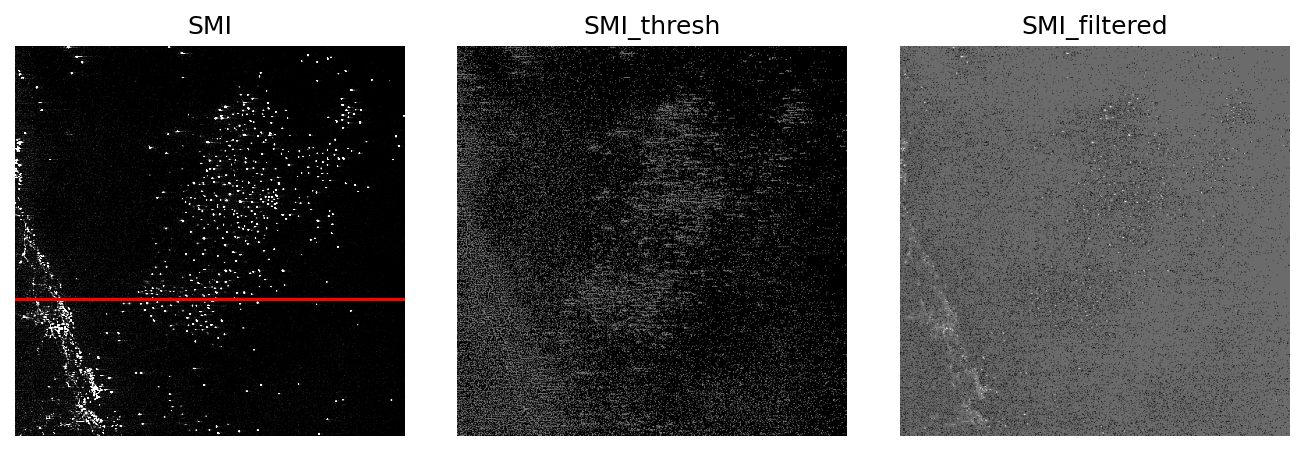

In [30]:
fig,ax = plt.subplots(1,3, figsize = [9,3], dpi = 150)
[axi.set_axis_off() for axi in ax.ravel()]

ax[0].set_title("SMI")
ax[0].imshow(SMI[1200:1700, 200:700], cmap = 'gray', vmax = 2)
ax[0].plot([0,499], [323,323], 'r')

ax[1].set_title("SMI_thresh")
ax[1].imshow(SMI_thresh_mask[1200:1700, 200:700], cmap = 'gray', vmax = 2)

ax[2].set_title("SMI_filtered")
ax[2].imshow(SMI_filtered[1200:1700, 200:700], cmap = 'gray', vmax = 2)

plt.tight_layout()

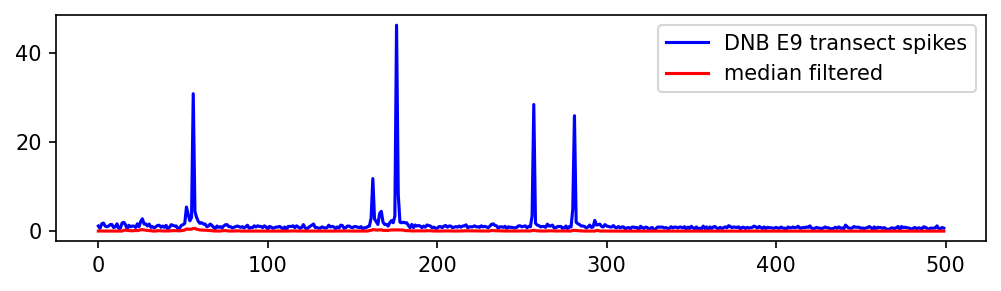

In [31]:
plt.figure(figsize = (8,2), dpi = 150)
plt.plot(DNB_E9[1523, 200:700], 'b', label = "DNB E9 transect spikes")
plt.plot(Jmed[1523, 200:700], 'r', label = "median filtered")
plt.legend()

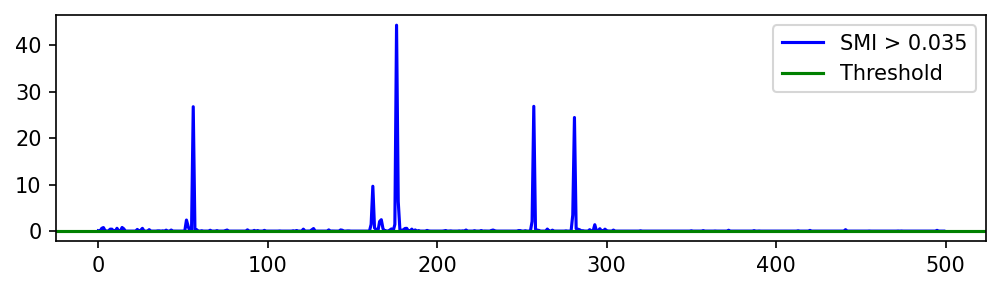

In [32]:
plt.figure(figsize = (8,2), dpi = 150)
plt.plot(SMI[1523, 200:700], 'blue', label = "SMI > 0.035")
plt.axhline(0.035, color = 'g', label = "Threshold")
plt.legend()

#### Spike Height Index

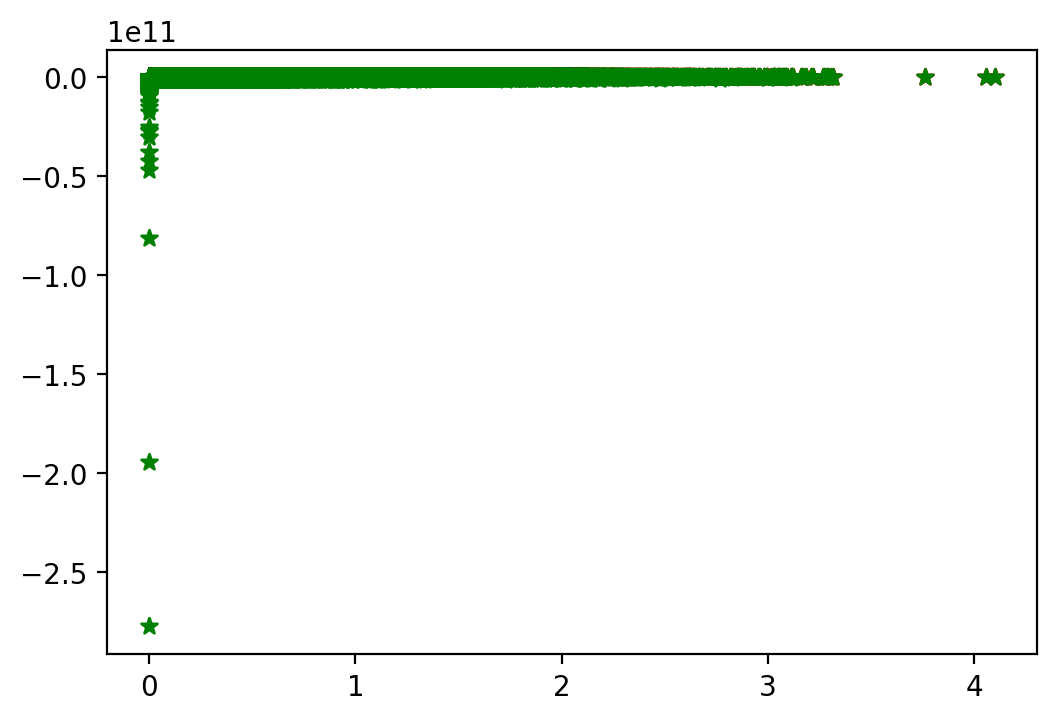

,0,1,2,3,4,5,6,7,8,9,...,4054,4055,4056,4057,4058,4059,4060,4061,4062,4063
0,0.000000e+00,-5.954249e-01,2.739193e-01,-1.772780e+00,8.322480e-02,-7.602152e-01,-3.329179e-01,5.995511e-01,-2.988811e+00,-3.237230e-01,...,-6.641804e-01,-2.308118e+00,1.402003e-01,-8.350262e+08,-2.308119e+00,4.278850e-01,-2.029491e-01,-3.955577e+00,1.894948e-01,-1.971229e+00
1,-4.140386e+08,-2.761986e+00,-3.261957e+00,-6.559786e+00,-3.545683e+00,-3.011080e-01,-1.143592e+09,5.000001e-01,8.221692e-02,-2.540982e+00,...,-3.150626e+08,-3.150626e+08,-5.055647e-01,-1.761848e+00,1.599645e-01,-4.549989e+00,-1.083848e+08,-5.217406e+08,-2.540730e+00,-2.146982e-01
2,-1.557608e+09,2.210230e-01,2.210230e-01,2.210230e-01,2.210230e-01,2.210230e-01,2.210230e-01,-9.929478e-01,2.210230e-01,2.210230e-01,...,2.210230e-01,2.210230e-01,2.210230e-01,2.210230e-01,2.196483e-01,2.210230e-01,-3.841895e+00,2.210230e-01,2.210230e-01,2.210230e-01
3,0.000000e+00,-7.788039e+08,0.000000e+00,-8.948722e+08,0.000000e+00,-4.131536e+00,-6.860796e-01,0.000000e+00,-4.117683e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,-5.834189e+08,-5.708871e+08,-3.503382e-01,-6.867579e+08,0.000000e+00,-5.780430e+08,-6.813820e+08,-4.675482e+08
4,0.000000e+00,-6.343455e+08,-6.343455e+08,-6.343455e+08,-6.343455e+08,-6.343455e+08,-6.343455e+08,-6.343455e+08,-6.343455e+08,-6.343455e+08,...,-6.738946e+08,-7.809429e+08,-6.343455e+08,-6.343455e+08,-6.343455e+08,-6.343455e+08,-6.343455e+08,-6.343455e+08,-6.343455e+08,-6.343455e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3227,-9.363890e+08,-7.368193e+08,-7.368193e+08,-7.368193e+08,-7.368193e+08,-7.368193e+08,-7.368193e+08,-7.368193e+08,-7.368193e+08,-7.368193e+08,...,-7.368193e+08,-7.368193e+08,-7.368193e+08,-7.368193e+08,-7.368193e+08,-7.368193e+08,-7.368193e+08,-7.368193e+08,-7.368193e+08,-7.368193e+08
3228,-1.058876e+09,-2.502711e+00,-2.502711e+00,-2.502711e+00,-2.502711e+00,-2.502711e+00,-2.502711e+00,-2.502711e+00,-2.502711e+00,-2.502711e+00,...,-2.502711e+00,-2.502711e+00,-3.540528e+00,-2.502711e+00,-1.007802e+09,-4.894492e+08,-6.967904e+08,-4.894492e+08,-2.502711e+00,-2.502711e+00
3229,-1.478494e+09,2.421680e-01,2.421680e-01,-2.081051e-01,2.421680e-01,-1.550849e-01,2.421680e-01,1.562141e-01,1.801207e-01,6.541261e-03,...,-1.019414e+01,3.179357e-02,2.421680e-01,-1.159427e+00,2.421680e-01,2.421680e-01,2.421680e-01,2.421680e-01,1.972528e-01,2.421680e-01
3230,-8.351911e+08,-1.985192e-01,-4.496000e-01,0.000000e+00,-5.543416e-02,0.000000e+00,-5.728261e-01,-2.345786e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,-4.261084e-01,0.000000e+00,0.000000e+00,-1.682188e+00,-9.556722e-02,0.000000e+00,-3.816562e-01,-3.798305e-01


In [33]:
## Spike Height Index (DOC OCAMPO's CODE)
SHI = spikeHeightIndexing(DNB_E9,num_lines,num_pixels)

plt.figure(dpi = 200)
plt.scatter(DNB_log, SHI*(SHI>=0.75), marker = "*", c = 'r')
plt.scatter(DNB_log, SHI*(SHI<0.75), marker = "*", c = 'g')
plt.show()

pd.DataFrame(SHI)

In [34]:
# Sir Rene's Code
SHI_h = np.zeros(shape = np.shape(DNB_E9))
SHI_v = np.zeros(shape = np.shape(DNB_E9))

for v in range(1, num_pixels-1):
    #Along Vertical
    #Averaging the left and right pixels
    SHI_v[:,v] = (DNB_E9[:,v] - 0.5*(DNB_E9[:,v-1]+DNB_E9[:,v+1]))/DNB_E9[:,v]
        
#     SHI_v[:,0] = (DNB_E9.data[:,1] - 0.5*(DNB_E9[:,v-1]+DNB_E9[:,v+1]))/DNB_E9[:,v]

for h in range(1, num_lines-1):
    #Along Horizontal
    #Averaging the left and right pixels
    SHI_h[h,:] = (DNB_E9[h,:] - 0.5*(DNB_E9[h-1,:]+DNB_E9[h+1,:]))/DNB_E9[h,:]
    
SHI = np.minimum(SHI_h, SHI_v)

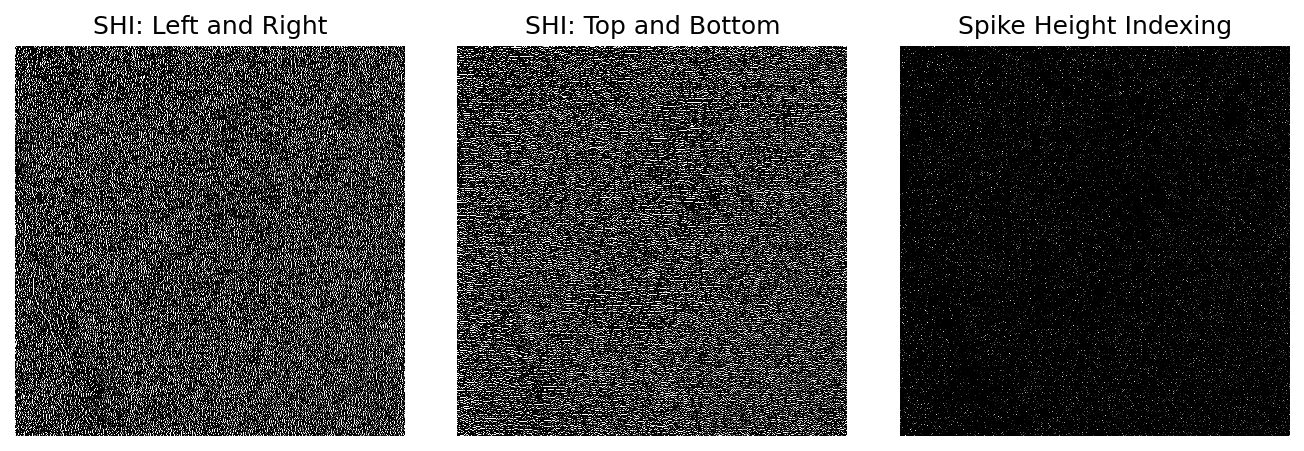

In [35]:
fig,ax = plt.subplots(1,3, figsize = [9,3], dpi = 150)
[axi.set_axis_off() for axi in ax.ravel()]

ax[0].set_title("SHI: Left and Right")
ax[0].imshow(SHI_v[1200:1700, 200:700], cmap = 'gray', vmin = 0, vmax = 0.1)

ax[1].set_title("SHI: Top and Bottom")
ax[1].imshow(SHI_h[1200:1700, 200:700], cmap = 'gray', vmin = 0, vmax = 0.1)

ax[2].set_title("Spike Height Indexing")
ax[2].imshow(SHI[1200:1700, 200:700], cmap = 'gray', vmin = 0, vmax = 0.2)

plt.tight_layout()

### D.4. Local Maxima Detection

In [36]:
## Local Maxima Detection
data = DNB_log
data[np.isnan(data)] = 0
# BW = imregionalmax(data,8)
# maxima_shape = np.ones((8, 8))
lm = scipy.ndimage.filters.maximum_filter(data, 8)
BW = (data == lm) #// convert local max values to binary mask
BW

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False,  True, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False,  True],
       [False, False, False, ..., False, False,  True]])

Spike Height Indexing
Minimum Value: -194215622694.2818
Maximum Value: 0.9999999992907463
Variance: 8275558541189239.0
Array Shape: (3232, 4064)

Local Maxima
Minimum Value: 0.0
Maximum Value: 4.1003026861167235
Variance: 0.06914559822217387
Array Shape: (3232, 4064)

Binary Mask of Local Maxima
Minimum Value: False
Maximum Value: True
Variance: 0.21135428072440907
Array Shape: (3232, 4064)



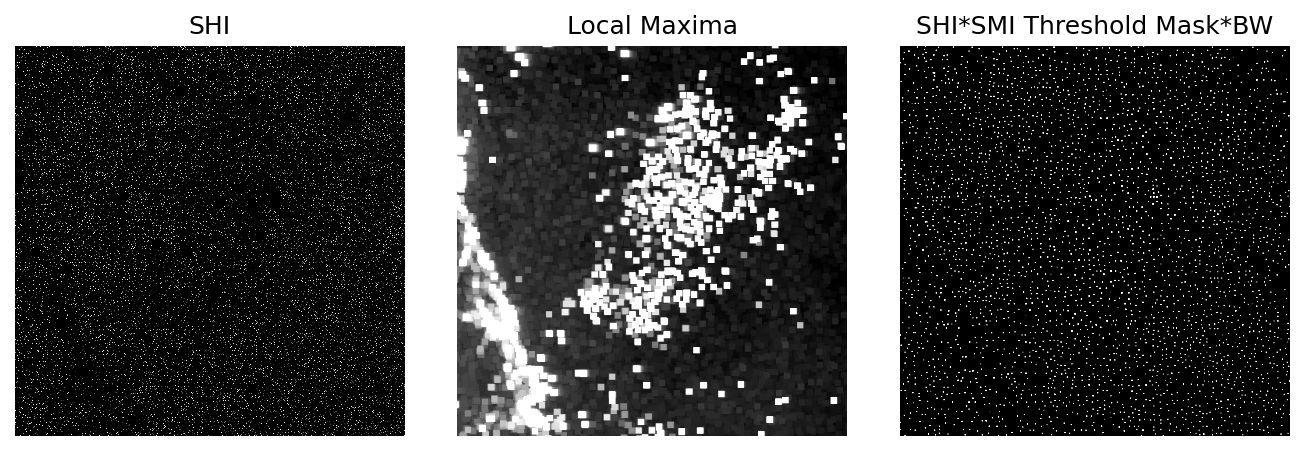

In [37]:
# Sanity Check: Statistically assess SHI

print("Spike Height Indexing")
stats(SHI)
print("")
print("Local Maxima")
stats(lm)
print("")
print("Binary Mask of Local Maxima")
stats(BW)
print("")

fig,ax = plt.subplots(1,3, figsize = [9,3], dpi = 150)
[axi.set_axis_off() for axi in ax.ravel()]

ax[0].set_title("SHI")
ax[0].imshow(SHI[1200:1700, 200:700], cmap = 'gray', vmin = 0, vmax = 0.1)

ax[1].set_title("Local Maxima")
ax[1].imshow(lm[1200:1700, 200:700], cmap = 'gray', vmin = 0, vmax = 1)

ax[2].set_title("SHI*SMI Threshold Mask*BW")
ax[2].imshow((SHI*SMI_thresh_mask*BW)[1200:1700, 200:700], cmap = 'gray', vmin = 0, vmax = 0.1)

plt.tight_layout()

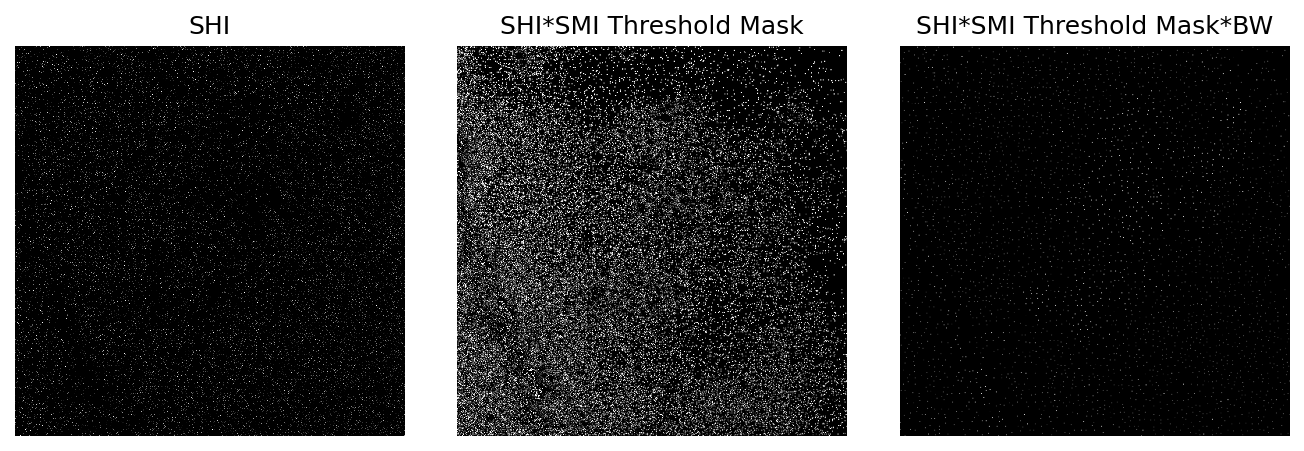

In [38]:
fig,ax = plt.subplots(1,3, figsize = [9,3], dpi = 150)
[axi.set_axis_off() for axi in ax.ravel()]

ax[0].set_title("SHI")
ax[0].imshow(SHI[1200:1700, 200:700], cmap = 'gray', vmin = 0, vmax = 0.2)

ax[1].set_title("SHI*SMI Threshold Mask")
ax[1].imshow((SHI*SMI_thresh_mask)[1200:1700, 200:700], cmap = 'gray', vmin = 0, vmax = 0.2)

ax[2].set_title("SHI*SMI Threshold Mask*BW")
ax[2].imshow((SHI*SMI_thresh_mask*BW)[1200:1700, 200:700], cmap = 'gray', vmin = 0, vmax = 0.75)

plt.tight_layout()

In [39]:
SHI_ = SHI*SMI_thresh_mask*BW
SHI = (SHI>0)*SHI

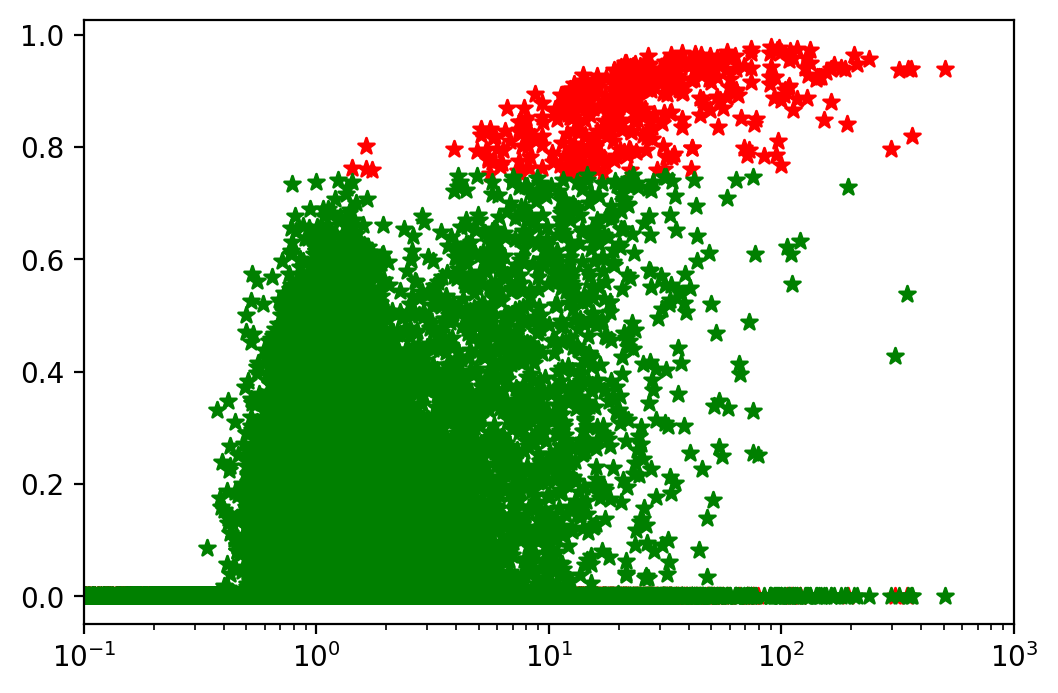

In [40]:
# DNB_observations = file_VNP02['observation_data']['DNB_observations'][:]
plt.figure(dpi = 200)
plt.scatter(DNB_E9[1200:1700, 200:700], (SHI*(SHI>=0.75))[1200:1700, 200:700], marker = "*", c = 'r')
plt.scatter(DNB_E9[1200:1700, 200:700], (SHI*(SHI<0.75))[1200:1700, 200:700], marker = "*", c = 'g')
plt.xscale('log')
plt.xlim(0.1,1000)
plt.show()

#### Sharpness Index

100%|██████████████████████████████████████████████████████████████████████████████| 405/405 [4:19:41<00:00, 38.47s/it]


s_map1


100%|████████████████████████████████████████████████████████████████████████████████| 405/405 [01:27<00:00,  4.60it/s]


s_map2
(3232, 4064)
(3232, 4064)
s3


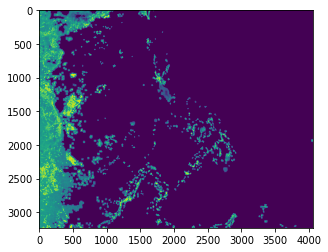

In [41]:
## Sharpness Index
SI = sharpnessIndexing(DNB_log)
# SI = np.pad(SI, (0, 1))
plt.imshow(SI)

,0,1,2,3,4,5,6,7,8,9,...,4054,4055,4056,4057,4058,4059,4060,4061,4062,4063
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
4,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3227,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3228,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3229,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3230,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


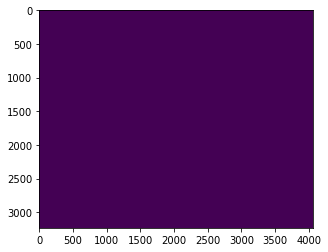

In [42]:
## Lightning Detection
NoLightning = lightningDetection(DNB_log,num_lines,num_pixels,num_scans)
# pd.DataFrame(NoLightning)
plt.imshow(NoLightning)
pd.DataFrame(NoLightning)

### D.5. Local Maxima Detection

In [43]:
## Local Maxima Detection
data = DNB_log
data[np.isnan(data)] = 0
# BW = imregionalmax(data,8)
# maxima_shape = np.ones((8, 8))
lm = scipy.ndimage.filters.maximum_filter(data, 8)
BW = (data == lm) #// convert local max values to binary mask
BW

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False,  True, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False,  True],
       [False, False, False, ..., False, False,  True]])

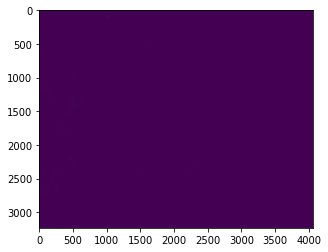

In [44]:
## Quality Flagging
VBD_QualityFlags = qflagging(DNB_E9,SMI_log,NoLightning,SI,SHI, SMI_thresh_mask,land_water_mask, BW, num_lines,num_pixels)
plt.imshow(VBD_QualityFlags == 1) 

In [25]:
# Boat Detection Geolocation
strong = VBD_QualityFlags == 1

Boat_Lat = Lat * strong
Boat_Lon = Lon * strong

# Create geodataframe from numpy arrays
df = pd.DataFrame({'lon':BoatsDetected_Lon,'lat':BoatsDetected_Lat})
df['coords'] = list(zip(df['lon'],df['lat']))
df['coords'] = df['coords'].apply(Point)
points = gpd.GeoDataFrame(df, geometry='coords', crs='EPSG:4326')
points

,lat,lon,coords
0,23.223425,117.165390,POINT (117.16539 23.22342)
1,23.185743,116.787796,POINT (116.78780 23.18574)
2,23.127056,117.071556,POINT (117.07156 23.12706)
3,22.701553,119.923584,POINT (119.92358 22.70155)
4,22.608633,120.209976,POINT (120.20998 22.60863)
...,...,...,...
1976,2.861969,108.611633,POINT (108.61163 2.86197)
1977,2.700131,109.696655,POINT (109.69666 2.70013)
1978,2.590625,110.430046,POINT (110.43005 2.59063)
1979,1.015064,120.614052,POINT (120.61405 1.01506)


## E. Export 

### 1.5.1 Limit to PAR

In [27]:
# Open the Philippine Area of Responsibility shapefile
par = gpd.GeoDataFrame.from_file('philippineareaofresponsibility\Philippine_Area_of_Responsibility.shp').to_crs("EPSG:4326")
par

,id,geometry
0,0,"POLYGON ((120.00000 25.00000, 135.00000 25.000..."


In [28]:
# Perform spatial join to match points and polygons import geopandas as gpd
pointInPolys = gpd.sjoin(points, par, how='left', op = "within")

# Select only the points within PAR
pnt_par = points[pointInPolys.id==0.0]
pnt_par

,lat,lon,coords
4,22.608633,120.209976,POINT (120.20998 22.60863)
6,22.558376,120.237503,POINT (120.23750 22.55838)
9,22.524368,120.239594,POINT (120.23959 22.52437)
12,22.468742,120.291351,POINT (120.29135 22.46874)
94,20.023914,120.307304,POINT (120.30730 20.02391)
...,...,...,...
1682,5.322806,120.089005,POINT (120.08900 5.32281)
1686,6.031889,115.312622,POINT (115.31262 6.03189)
1712,5.810332,115.237488,POINT (115.23749 5.81033)
1720,5.644165,115.886261,POINT (115.88626 5.64417)


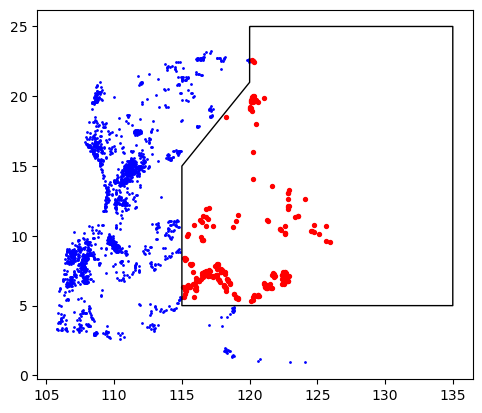

In [29]:
# Visualize
base = par.boundary.plot(linewidth=1, edgecolor="black")
points.plot(ax=base, linewidth=1, color="blue", markersize=1)
pnt_par.plot(ax=base, linewidth=1, color="red", markersize=8)
plt.show()

### 1.5.2 Export

In [35]:
# Create output folder if necessary
os.makedirs("output",exist_ok=True)

# Export to KML 
kml = simplekml.Kml()

for ind in pnt_par.index:
    kml.newpoint(name=ind, coords=[(float(df['lon'][ind]), float(df['lat'][ind]))])

filename = "output\Boats Detected_" + file_VNP02.RangeBeginningDate + ".kml"   
kml.save(filename)

# Export to CSV
filename = "output\Boats Detected_" + file_VNP02.RangeBeginningDate + ".csv"
np.savetxt(filename, pnt_par.iloc[:, 0:2], delimiter=",")